Connected to Python 3.14.6

In [ ]:
import pandas as pd

In [ ]:
import os
print(os.getcwd())

script_dir = os.path.dirname(os.path.abspath(__file__))
print(script_dir)

c:\Users\Wu\College_App_2028\SciFi_20260616
c:\Users\Wu\College_App_2028\SciFi_20260616


In [ ]:
print(df.shape) 

(6920, 2)


In [ ]:
df.head(500).to_excel("clairett_sentiment_data_head500.xlsx", index=False)

In [ ]:
#it seems the data is a movie review/comment about a 1933 <<movie Les vingt-huit jours de Clairette>>
url = "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['text','label'])

df.head()

#label: 0 = negative sentiment, 1=positive sentiment

,text,label
0,"a stirring , funny and finally transporting re...",1
1,apparently reassembled from the cutting room f...,0
2,they presume their audience wo n't sit still f...,0
3,this is a visually stunning rumination on love...,1
4,jonathan parker 's bartleby should have been t...,1


In [ ]:
print(df.shape)  
#6920,2 

(6920, 2)


In [ ]:
"""  now apply VADER sentiment analysis (fast + easy, generate scores -1 to 1)"""


from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

#VADER generates 4 columns: neg, neu, pos, compound
#compound is the overall sentiment score from -1 (most negative) to 1 (most positive)
#neg/neu/pos - they always sum up to 1 (proportions of the text being negative, neutral, or positive) 
#use compound for the overall sentiment score, use neg/neu/pos for the individual sentiment components
    

df["vader_neg"] = df["text"].apply(lambda x: analyzer.polarity_scores(x)["neg"])
df["vader_neu"] = df["text"].apply(lambda x: analyzer.polarity_scores(x)["neu"])
df["vader_pos"] = df["text"].apply(lambda x: analyzer.polarity_scores(x)["pos"])
df["vader_compound"] = df["text"].apply(lambda x: analyzer.polarity_scores(x)["compound"])
print(df.head()) 

                                                text  label  vader_neg  \
0  a stirring , funny and finally transporting re...      1      0.146   
1  apparently reassembled from the cutting room f...      0      0.120   
2  they presume their audience wo n't sit still f...      0      0.000   
3  this is a visually stunning rumination on love...      1      0.146   
4  jonathan parker 's bartleby should have been t...      1      0.000   

   vader_neu  vader_pos  vader_compound  
0      0.591      0.264          0.4588  
1      0.880      0.000         -0.1280  
2      0.923      0.077          0.4404  
3      0.599      0.255          0.4404  
4      1.000      0.000          0.0000  


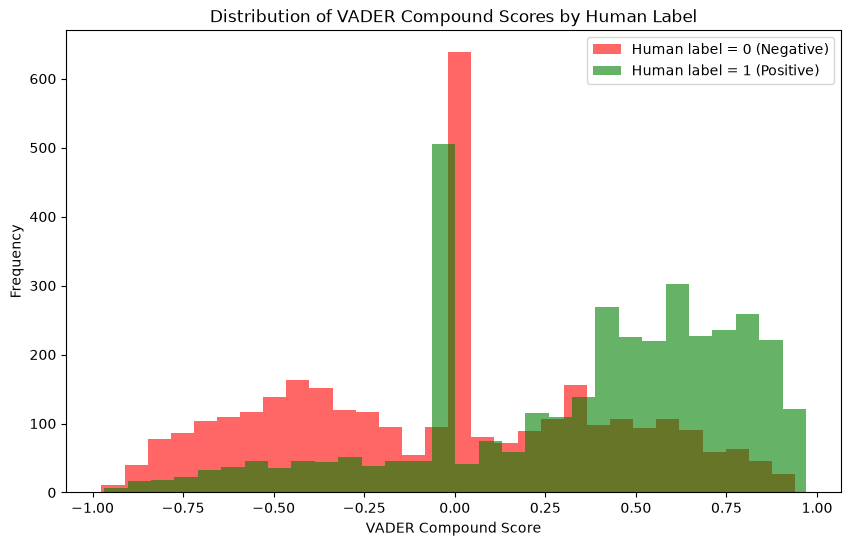

In [ ]:
# now check if sentiment scores are aligned with the human-annotated labels 

#approach 1: check the distribution of VADER scores for each label
neg_scores = df[df["label"] == 0]["vader_compound"]
pos_scores = df[df["label"] == 1]["vader_compound"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(neg_scores, bins=30, alpha=0.6, color='red', label='Human label = 0 (Negative)')
plt.hist(pos_scores, bins=30, alpha=0.6, color='green', label='Human label = 1 (Positive)')

plt.title("Distribution of VADER Compound Scores by Human Label")
plt.xlabel("VADER Compound Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

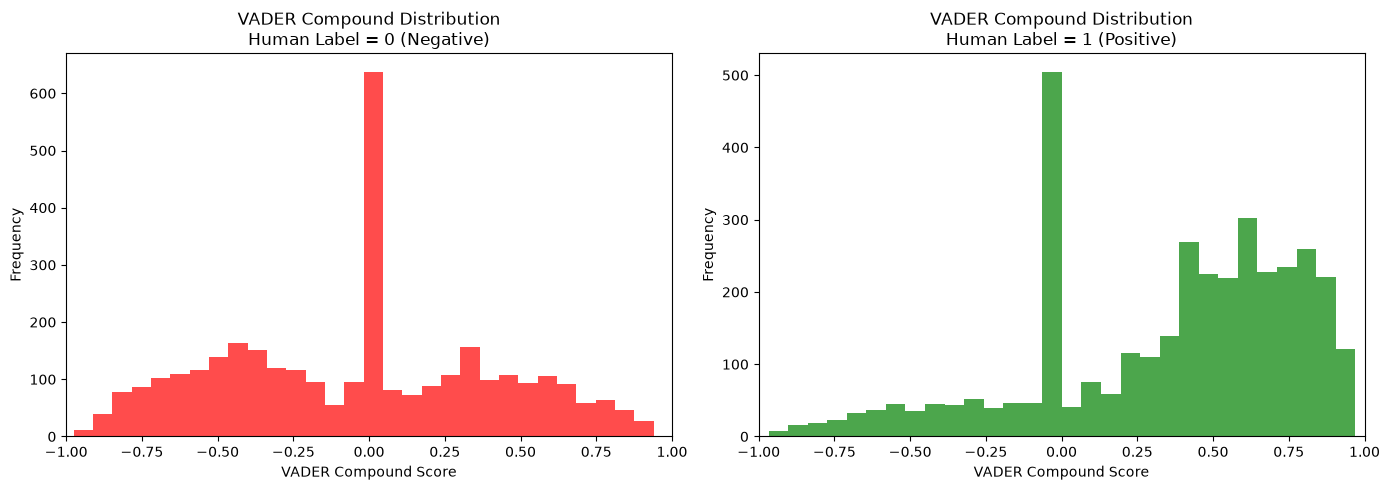

In [ ]:
# Create side-by-side plots
plt.figure(figsize=(14,5))

# Plot 1 — Negative class
plt.subplot(1, 2, 1)
plt.hist(neg_scores, bins=30, color='red', alpha=0.7)
plt.title("VADER Compound Distribution\nHuman Label = 0 (Negative)")
plt.xlabel("VADER Compound Score")
plt.ylabel("Frequency")
plt.xlim(-1, 1)

# Plot 2 — Positive class
plt.subplot(1, 2, 2)
plt.hist(pos_scores, bins=30, color='green', alpha=0.7)
plt.title("VADER Compound Distribution\nHuman Label = 1 (Positive)")
plt.xlabel("VADER Compound Score")
plt.ylabel("Frequency")
plt.xlim(-1, 1)

plt.tight_layout()
plt.show()

In [ ]:
print(df['label'].value_counts(dropna=False))

label
1    3610
0    3310
Name: count, dtype: int64


In [ ]:
""" 
The widely accepted, research-standard threshold is:
compound > 0.05 → positive
compound < -0.05 → negative
otherwise → neutral

Since human-annotated labels are binary (0 or 1), we will map the VADER scores to the same binary labels:
- VADER score > 0.05 → 1 (Positive)
- VADER score <= 0.05 → 0 (Negative)

Reference: 
Hutto, C.J. & Gilbert, E.E. (2014).  
VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text.  
Proceedings of ICWSM (International Conference on Web and Social Media).

https://ojs.aaai.org/index.php/ICWSM/article/view/14550

""" 

def vader_to_binary(score):
    # Official VADER rule:
    # compound > 0.05 → positive (1)
    # otherwise → negative (0)
    return 1 if score > 0.05 else 0

df["vader_binary"] = df["vader_compound"].apply(vader_to_binary)

print(df['vader_binary'].value_counts(dropna=False)) 
print(pd.crosstab(df['label'], df['vader_binary'], dropna=False))  

vader_binary
1    3794
0    3126
Name: count, dtype: int64
vader_binary     0     1
label                   
0             2116  1194
1             1010  2600


In [ ]:
def vader_to_three(score):
    if score > 0.05:
        return "pos"
    elif score < -0.05:
        return "neg"
    else:
        return "neu"

df["vader_3class"] = df["vader_compound"].apply(vader_to_three)

print(df['vader_3class'].value_counts(dropna=False)) 
print(pd.crosstab(df['label'], df['vader_3class'], dropna=False))  

vader_3class
pos    3794
neg    1953
neu    1173
Name: count, dtype: int64
vader_3class   neg  neu   pos
label                        
0             1447  669  1194
1              506  504  2600


In [ ]:
def vader_to_three(score):
    if score > 0.05:
        return "pos"
    elif score < -0.05:
        return "neg"
    else:
        return "neu"

df["vader_3class"] = df["vader_compound"].apply(vader_to_three)

print(df['vader_3class'].value_counts(dropna=False)) 
print(pd.crosstab(df['vader_3class'], df['label'], dropna=False))  

vader_3class
pos    3794
neg    1953
neu    1173
Name: count, dtype: int64
label            0     1
vader_3class            
neg           1447   506
neu            669   504
pos           1194  2600


In [ ]:
pearson = df["label"].corr(df["vader_compound"])
print("Pearson correlation:", pearson) 

Pearson correlation: 0.4159198960019873
